实验过程中发现dataparser的随机种子会对重建+3D分割指标产生较大影响，应该是 splits 不同导致的(good: dice:0.70, bad: dice:0.60)。下面进行相关可视化分析。

In [1]:
from pathlib import Path
import json
from internal.dataparsers.xray_dataparser.meta import XRayMetaLoader

meta = XRayMetaLoader().load(Path("../../data/Diseased_17"))

In [2]:
with open("./splits_bad_seed-42.json", "r") as f:
    splits_seed42 = json.load(f)

train_splits_bad = splits_seed42["train"]
test_splits_bad = splits_seed42["test"]

train_splits_bad[:5]

[26, 27, 84, 35, 50]

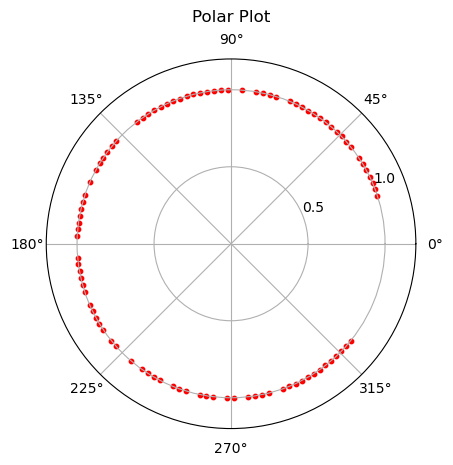

In [3]:
alphas_train = meta.alphas_radians[train_splits_bad]

%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

radii = np.ones_like(alphas_train)

fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})

ax.scatter(alphas_train, radii, color='red', marker='o', s=10, label='Data Points')

ax.set_rmax(1.2)          # 设置圆周的最大半径范围  # type: ignore
ax.set_rticks([0.5, 1.0]) # 设置半径刻度线      # type: ignore
ax.grid(True)             # 显示极坐标网格
plt.title("Polar Plot", va='bottom')

plt.show()

从上图可以看出，角度分布相对均匀，可视范围也并没有变小。因此角度不是主要影响因素。可能是采样造成的相位缺失导致的质量下降

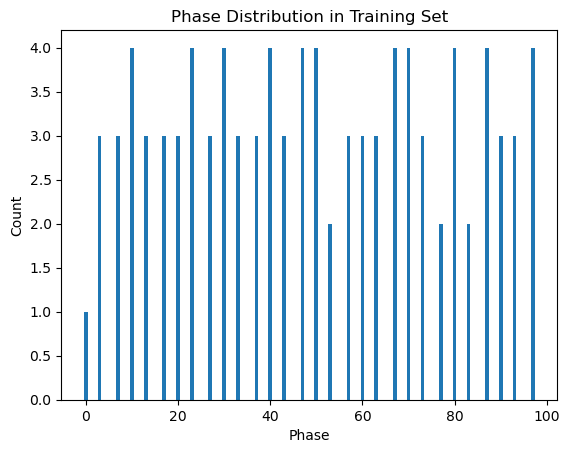

In [4]:
phases_bad = meta.phase_array[train_splits_bad]
phases_bad_int = np.round(phases_bad*100).astype(int)

from collections import Counter

hist = Counter(phases_bad_int)

plt.bar(hist.keys(), hist.values())
plt.xlabel("Phase")
plt.ylabel("Count")
plt.title("Phase Distribution in Training Set")
plt.show()

上图中可见，phase=0的训练帧只有一帧，而我们计算3D指标时会将高斯点云形变到 phase=0 后再提取 volume。训练数据的缺失导致了最后看到的volume形状和真实值有所偏差，进而导致和真实值的交集下降，这会导致 dice 和 iou 的下降。在改用 使用全部帧重建后这个问题消失。我们可以在 good splits上验证一下，看看是否存在类似的现象。

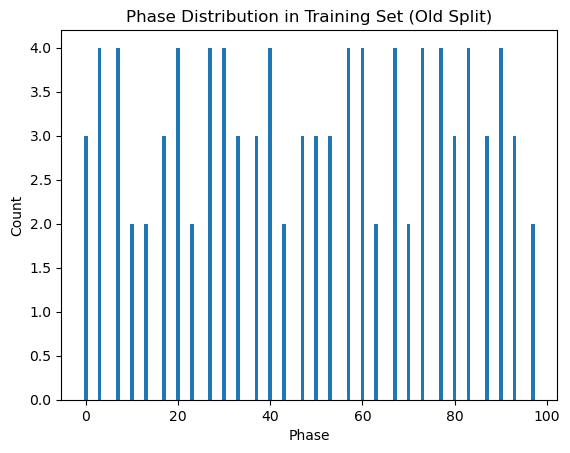

In [5]:
with open("./splits_good_seed-0.json", "r") as f:
    splits_old = json.load(f)

train_splits_old = splits_old["train"]

phases_train_old = meta.phase_array[train_splits_old]
phases_train_old_int = np.round(phases_train_old*100).astype(int)

hist_old = Counter(phases_train_old_int)
plt.bar(hist_old.keys(), hist_old.values())
plt.xlabel("Phase")
plt.ylabel("Count")
plt.title("Phase Distribution in Training Set (Old Split)")
plt.show()

可见，good splits 上 phase=0 的训练帧数量相对较多（有3帧），这也解释了为什么 good splits 上的3D指标表现更好。